In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
oil = pd.read_csv('/content/drive/MyDrive/agg_oil_data.csv')

# Calculate the difference in months from Jan 1, 1970 (standard I hear)
oil['time_idx'] = (oil['Year'] - 2000) * 12 + (oil['Month'] - 1)

# Generate sinusoidal features to model monthly seasonality
oil['month_sin'] = np.sin(2 * np.pi * oil['Month'] / 12)
oil['month_cos'] = np.cos(2 * np.pi * oil['Month'] / 12)

# Typo from original data
oil.rename(columns={'ENERGY SOURCE              (UNITS)': 'ENERGY SOURCE (UNITS)'}, inplace=True)

# Set to ordered format
oil['Period'] = pd.to_datetime(oil['Period'])

oil.drop(columns=['State_Code', 'TYPE OF PRODUCER', 'ENERGY SOURCE (UNITS)'], inplace=True)

oil['CONSUMPTION'] = pd.to_numeric(
    oil['CONSUMPTION'].astype(str).str.replace(',', ''),
    errors='coerce'
).astype(pd.Int64Dtype())

print(oil.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5947 entries, 0 to 5946
Data columns (total 14 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Period                                 5947 non-null   datetime64[ns]
 1   Price                                  5947 non-null   float64       
 2   Year                                   5947 non-null   int64         
 3   Month                                  5947 non-null   int64         
 4   state                                  5947 non-null   object        
 5   CONSUMPTION                            5947 non-null   Int64         
 6   Treasury Yield Spread (10Y-2Y)         5947 non-null   float64       
 7   Inflation Rate (%)                     5947 non-null   float64       
 8   Industrial Production Index            5947 non-null   float64       
 9   temperature (F)                        5947 non-null   float64 

# Linear Regression

In [4]:
from sklearn.linear_model import LinearRegression

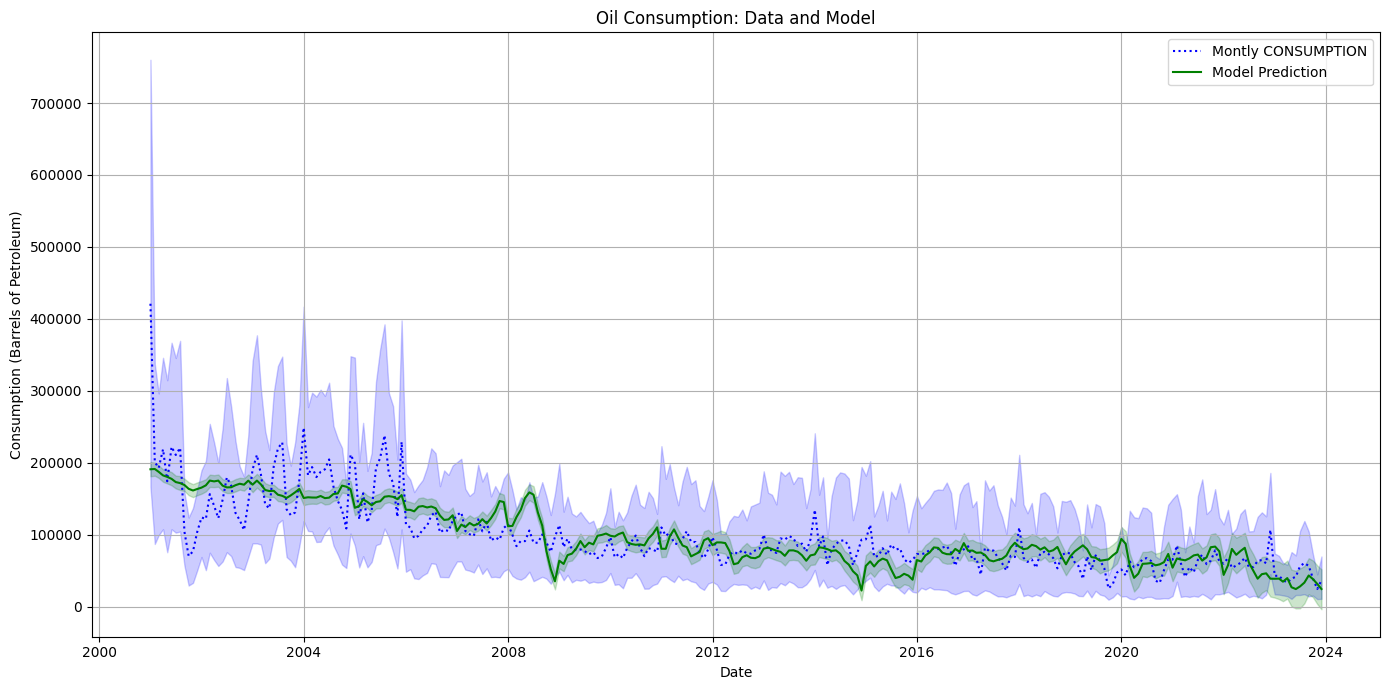

In [117]:
pred_cols = ['Price', 'Treasury Yield Spread (10Y-2Y)', 'Inflation Rate (%)',
             'Industrial Production Index', 'temperature (F)', 'Electricity Price ($ per million BTU)',
             'time_idx', 'month_sin', 'month_cos']

X = oil[pred_cols]
y = oil['CONSUMPTION']

model = LinearRegression()
model.fit(X, y)

model_pred = model.predict(X)

plt.figure(figsize=(14, 7)) # Adjust figure size for better readability

# Original consumption data
sns.lineplot(x='Period', y=y, data=oil, label=f'Montly {y.name}', color='blue', linestyle=':')

# Model prediction
sns.lineplot(x=oil['Period'], y=model_pred, label='Model Prediction', color='green', linestyle='-')

plt.title('Oil Consumption: Data and Model')
plt.xlabel('Date')
plt.ylabel('Consumption (Barrels of Petroleum)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [118]:
print('\nCorrelation with CONSUMPTION:')
print(oil[['CONSUMPTION'] + pred_cols].corr()['CONSUMPTION'].sort_values(ascending=False))


Correlation with CONSUMPTION:
CONSUMPTION                              1.000000
Treasury Yield Spread (10Y-2Y)           0.058747
month_sin                                0.014994
Inflation Rate (%)                      -0.004821
month_cos                               -0.007374
temperature (F)                         -0.025592
Price                                   -0.072985
Industrial Production Index             -0.113374
time_idx                                -0.205801
Electricity Price ($ per million BTU)   -0.243982
Name: CONSUMPTION, dtype: float64


## Coefficient Confidence Intervals

In [120]:
from scipy import stats

alpha = 0.05 # for 95% confidence interval; use 0.01 for 99%-CI.

# the coefficients of the regression model
coefs = np.r_[[model.intercept_], model.coef_]
# build an auxiliary dataframe with the constant term in it
X_aux = X.copy().astype(float)
X_aux.insert(0, 'const', 1)
# degrees of freedom
dof = -np.diff(X_aux.shape)[0]
# Student's t-distribution table lookup
t_val = stats.t.isf(alpha/2, dof)
# MSE of the residuals
mse = np.sum((y - model.predict(X)) ** 2) / dof
# inverse of the variance of the parameters
var_params = np.diag(np.linalg.inv(X_aux.T.dot(X_aux)))
# distance between lower and upper bound of CI
gap = t_val * np.sqrt(mse * var_params)

conf_int = pd.DataFrame({'lower': coefs - gap, 'mid': coefs, 'upper': coefs + gap}, index=X_aux.columns)
display(round(conf_int, 3))

,lower,mid,upper
const,176868.694,313017.145,449165.596
Price,1060.048,1354.327,1648.605
Treasury Yield Spread (10Y-2Y),-12177.718,-5136.640,1904.438
Inflation Rate (%),5359.149,8643.492,11927.834
Industrial Production Index,-1444.433,-47.700,1349.033
temperature (F),-1000.875,-467.106,66.663
Electricity Price ($ per million BTU),-17026.426,-15258.398,-13490.371
time_idx,-260.847,-180.883,-100.919
month_sin,-9670.468,-557.623,8555.222
month_cos,-17771.389,-6285.171,5201.047


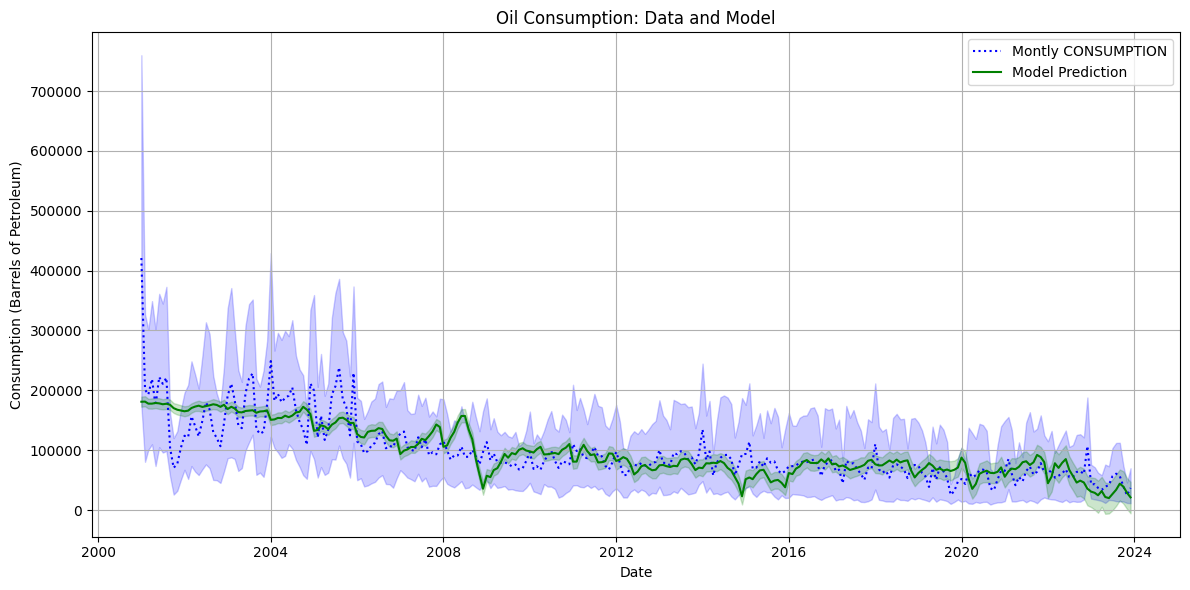

In [122]:
significant_cols = ['Price', 'Inflation Rate (%)', 'Electricity Price ($ per million BTU)', 'time_idx']

X = oil[significant_cols]
y = oil['CONSUMPTION']

model = LinearRegression()
model.fit(X, y)

model_pred = model.predict(X)

plt.figure(figsize=(12, 6)) # Adjust figure size for better readability

# Original consumption data
sns.lineplot(x='Period', y=y, data=oil, label=f'Montly {y.name}', color='blue', linestyle=':')

# Model prediction
sns.lineplot(x=oil['Period'], y=model_pred, label='Model Prediction', color='green', linestyle='-')

plt.title('Oil Consumption: Data and Model')
plt.xlabel('Date')
plt.ylabel('Consumption (Barrels of Petroleum)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [123]:
from scipy import stats

alpha = 0.05 # for 95% confidence interval; use 0.01 for 99%-CI.

# the coefficients of the regression model
coefs = np.r_[[model.intercept_], model.coef_]
# build an auxiliary dataframe with the constant term in it
X_aux = X.copy().astype(float)
X_aux.insert(0, 'const', 1)
# degrees of freedom
dof = -np.diff(X_aux.shape)[0]
# Student's t-distribution table lookup
t_val = stats.t.isf(alpha/2, dof)
# MSE of the residuals
mse = np.sum((y - model.predict(X)) ** 2) / dof
# inverse of the variance of the parameters
var_params = np.diag(np.linalg.inv(X_aux.T.dot(X_aux)))
# distance between lower and upper bound of CI
gap = t_val * np.sqrt(mse * var_params)

conf_int = pd.DataFrame({'lower': coefs - gap, 'mid': coefs, 'upper': coefs + gap}, index=X_aux.columns)
display(round(conf_int, 3))

,lower,mid,upper
const,257541.371,275458.318,293375.266
Price,1031.100,1286.663,1542.226
Inflation Rate (%),7116.921,9963.010,12809.100
Electricity Price ($ per million BTU),-17056.844,-15312.767,-13568.690
time_idx,-223.618,-155.082,-86.546


# State by State

,Price,Treasury Yield Spread (10Y-2Y),Inflation Rate (%),Industrial Production Index,temperature (F),Electricity Price ($ per million BTU),time_idx,month_sin,month_cos
PA,-0.360111,0.149634,-0.000744,-0.366650,-0.097500,-0.584700,-0.618146,0.058524,0.004161
WV,0.156588,0.059539,0.088677,-0.069674,-0.197007,0.133391,-0.015431,0.099497,0.140451
IL,-0.358627,0.155923,0.011776,-0.370676,-0.035533,-0.443942,-0.471863,0.091087,-0.041378


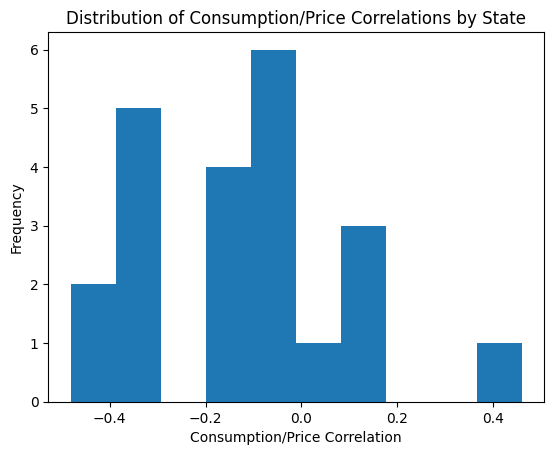

In [124]:
corrs = []

for state in oil['state'].unique():
  state_oil = oil[oil['state'] == state]
  corr = state_oil[['CONSUMPTION'] + pred_cols].corr()['CONSUMPTION'].drop('CONSUMPTION')
  corrs.append(corr)

corrs_df = pd.concat(corrs, axis=1).T
corrs_df.columns = pred_cols
corrs_df.index = oil['state'].unique()
display(corrs_df.head(3))
plt.hist(corrs_df['Price'])
plt.xlabel('Consumption/Price Correlation')
plt.ylabel('Frequency')
plt.title('Distribution of Consumption/Price Correlations by State')
plt.show()

In [125]:
np.var(corrs_df, axis=0).sort_values(ascending=False)

,0
time_idx,0.133554
Electricity Price ($ per million BTU),0.093176
Industrial Production Index,0.070658
Price,0.049599
Treasury Yield Spread (10Y-2Y),0.040531
Inflation Rate (%),0.019954
temperature (F),0.011133
month_cos,0.007922
month_sin,0.004919


## K-Means

In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

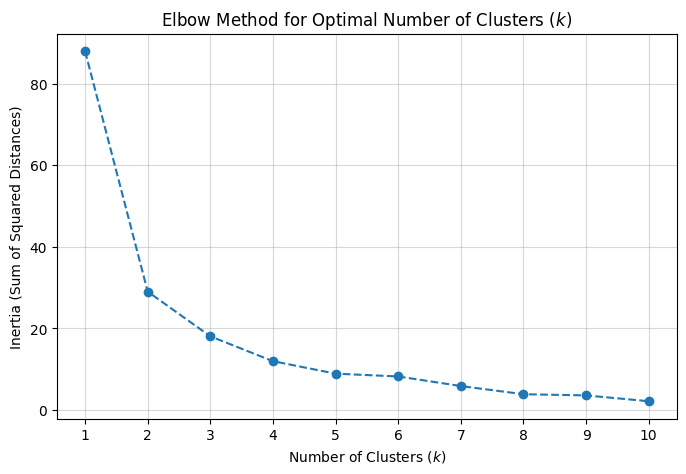

In [139]:
scaler = StandardScaler()
corrs_meaningful = corrs_df[['time_idx', 'Electricity Price ($ per million BTU)', 'Industrial Production Index', 'Price']]
corrs_scaled = scaler.fit_transform(corrs_meaningful)
corrs_scaled = pd.DataFrame(corrs_scaled, columns=corrs_meaningful.columns, index=corrs_meaningful.index)

# --- 3. Determine Optimal k using the Elbow Method ---
inertia = []
K_range = range(1, 11)

for k in K_range:
    # Use 'k-means++' initialization and 'auto' for n_init (modern best practice)
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_model.fit(corrs_scaled)
    inertia.append(kmeans_model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Number of Clusters ($k$)')
plt.xlabel('Number of Clusters ($k$)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.grid(True, alpha=0.5)
plt.xticks(K_range)
plt.show()

In [140]:
# We visually select k from the plot above.
k = 3
print(f"\n--- Selected Number of Clusters (k) = {k} ---")

# --- 4. K-Means Clustering ---
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(corrs_scaled)

# --- 5. Principal Component Analysis (PCA) ---
# Reduce the dimensions to 2 for easy plotting
pca = PCA(n_components=2)
principal_components = pca.fit_transform(corrs_scaled)

# Create a DataFrame for visualization
pca_df = pd.DataFrame(
    data=principal_components,
    columns=['PC 1', 'PC 2'],
    index=corrs_scaled.index
)
pca_df['Cluster'] = cluster_labels.astype(str)

print("\nExplained variance ratio by the 2 principal components:")
print(pca.explained_variance_ratio_)
print(f"Cumulative Explained Variance: {pca.explained_variance_ratio_.sum():.2f}")


--- Selected Number of Clusters (k) = 3 ---

Explained variance ratio by the 2 principal components:
[0.913145   0.07013867]
Cumulative Explained Variance: 0.98


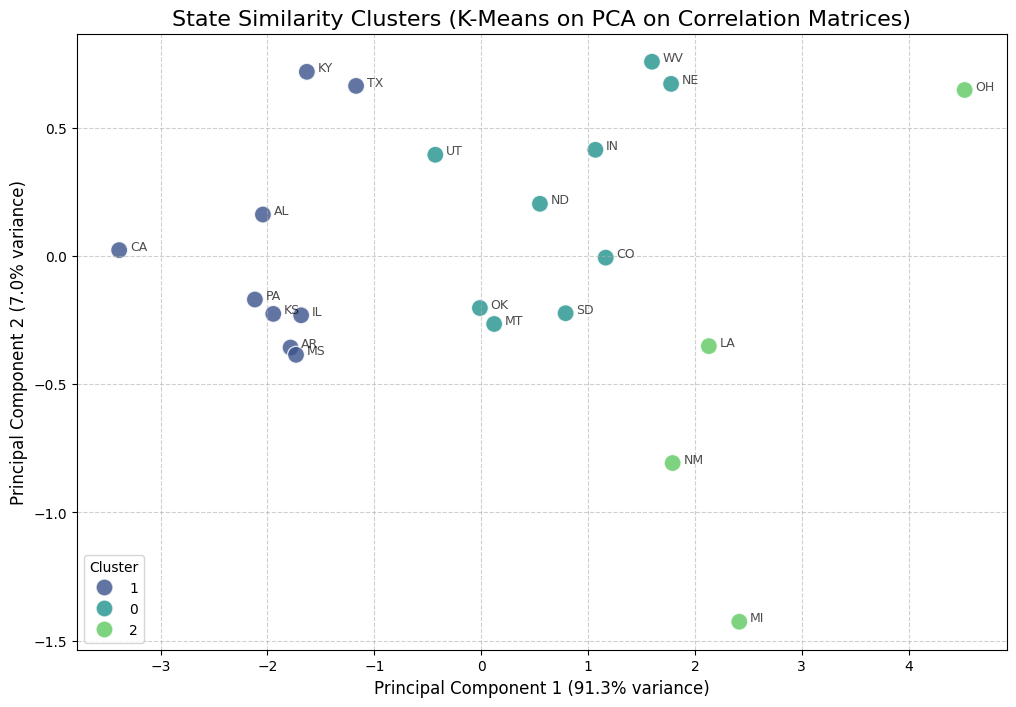

In [141]:
# PCA Scatterplot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC 1',
    y='PC 2',
    hue='Cluster',
    data=pca_df,
    palette='viridis',
    s=150,
    alpha=0.8,
    legend='full'
)

# Add state labels (annotations)
for i, state in enumerate(pca_df.index):
    plt.annotate(
        state,
        (pca_df['PC 1'].iloc[i] + 0.1, pca_df['PC 2'].iloc[i]),
        fontsize=9,
        alpha=0.7,
        ha='left'
    )

# Customize plot titles and axis labels
pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

plt.title(f'State Similarity Clusters (K-Means on PCA on Correlation Matrices)', fontsize=16)
plt.xlabel(f'Principal Component 1 ({pc1_var:.1f}% variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pc2_var:.1f}% variance)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster', loc='lower left')
plt.show()

# --- 7. Final Results DataFrame ---
final_clusters_df = pca_df[['Cluster']].copy()
final_clusters_df['State'] = final_clusters_df.index
final_clusters_df = final_clusters_df[['State', 'Cluster']].sort_values(by='Cluster')

In [143]:
for cluster in final_clusters_df['Cluster'].unique():
  print(f"\n--- Cluster {cluster} ---")
  print(final_clusters_df[final_clusters_df['Cluster'] == cluster]['State'].values)
  print(f"Correlations of Consumption with Price:\n{np.round(corrs_df['Price'].loc[final_clusters_df[final_clusters_df['Cluster'] == cluster]['State'].values].values, 2)}")
  print(f"Average Correlation: {corrs_df.loc[final_clusters_df[final_clusters_df['Cluster'] == cluster]['State'].values, 'Price'].mean():.2f}")


--- Cluster 0 ---
['OK' 'WV' 'MT' 'IN' 'CO' 'NE' 'ND' 'UT' 'SD']
Correlations of Consumption with Price:
[-0.17  0.16 -0.19  0.06 -0.03  0.16 -0.02 -0.09 -0.1 ]
Average Correlation: -0.02

--- Cluster 1 ---
['TX' 'MS' 'AR' 'PA' 'KY' 'KS' 'IL' 'AL' 'CA']
Correlations of Consumption with Price:
[-0.18 -0.38 -0.39 -0.36 -0.16 -0.36 -0.36 -0.32 -0.48]
Average Correlation: -0.33

--- Cluster 2 ---
['OH' 'LA' 'MI' 'NM']
Correlations of Consumption with Price:
[ 0.46  0.09 -0.09 -0.04]
Average Correlation: 0.11


We can compare states by their meaningfully distinct entries.

In [68]:
state_diff_cols = ['CONSUMPTION', 'temperature (F)', 'Electricity Price ($ per million BTU)']
oil_by_state = oil.groupby('state')[state_diff_cols].mean()

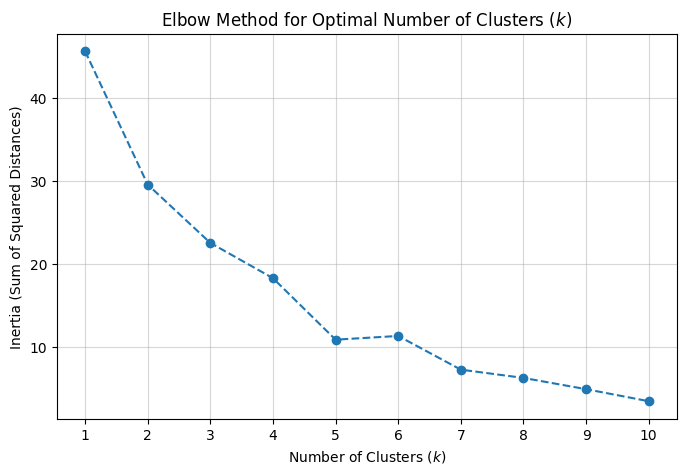

In [151]:
scaler = StandardScaler()
obs_scaled = scaler.fit_transform(oil_by_state)
obs_scaled = pd.DataFrame(obs_scaled, columns=oil_by_state.columns, index=oil_by_state.index).drop('LA')

# --- 3. Determine Optimal k using the Elbow Method ---
inertia = []
K_range = range(1, 11)

for k in K_range:
    # Use 'k-means++' initialization and 'auto' for n_init (modern best practice)
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_model.fit(obs_scaled)
    inertia.append(kmeans_model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Number of Clusters ($k$)')
plt.xlabel('Number of Clusters ($k$)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.grid(True, alpha=0.5)
plt.xticks(K_range)
plt.show()

In [152]:
# We visually select k from the plot above.
k = 4
print(f"\n--- Selected Number of Clusters (k) = {k} ---")

# --- 4. K-Means Clustering ---
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(obs_scaled)

# --- 5. Principal Component Analysis (PCA) ---
# Reduce the dimensions to 2 for easy plotting
pca = PCA(n_components=2)
principal_components = pca.fit_transform(obs_scaled)

# Create a DataFrame for visualization
pca_df = pd.DataFrame(
    data=principal_components,
    columns=['PC 1', 'PC 2'],
    index=obs_scaled.index
)
pca_df['Cluster'] = cluster_labels.astype(str)

print("\nExplained variance ratio by the 2 principal components:")
print(pca.explained_variance_ratio_)
print(f"Cumulative Explained Variance: {pca.explained_variance_ratio_.sum():.2f}")


--- Selected Number of Clusters (k) = 4 ---

Explained variance ratio by the 2 principal components:
[0.47173489 0.37986817]
Cumulative Explained Variance: 0.85


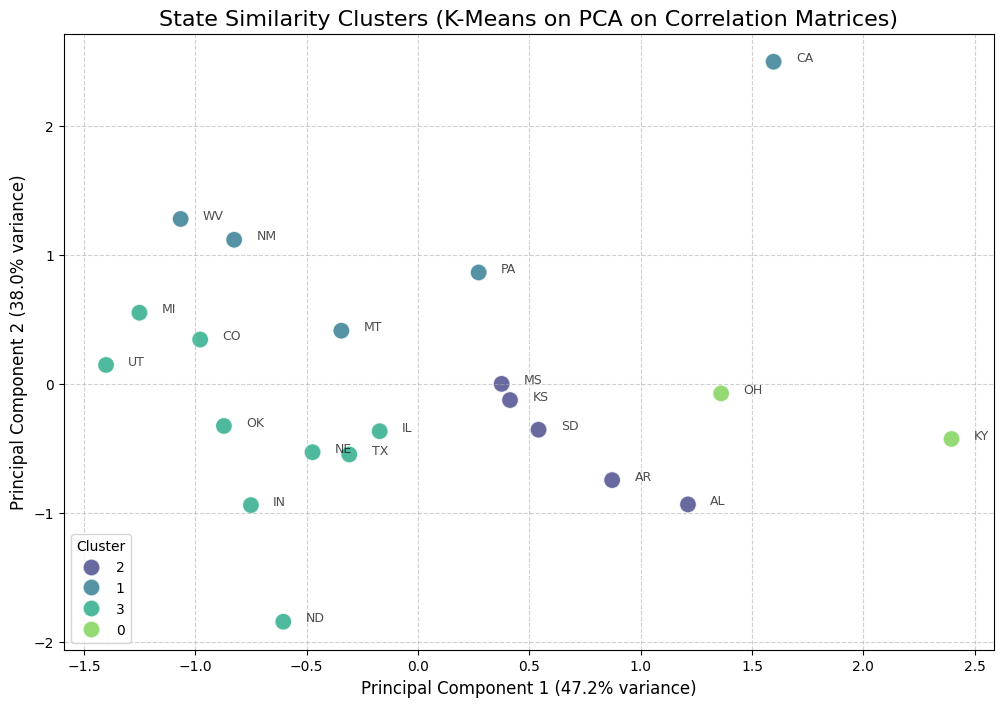

In [153]:
# PCA Scatterplot
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC 1',
    y='PC 2',
    hue='Cluster',
    data=pca_df,
    palette='viridis',
    s=150,
    alpha=0.8,
    legend='full'
)

# Add state labels (annotations)
for i, state in enumerate(pca_df.index):
    plt.annotate(
        state,
        (pca_df['PC 1'].iloc[i] + 0.1, pca_df['PC 2'].iloc[i]),
        fontsize=9,
        alpha=0.7,
        ha='left'
    )

# Customize plot titles and axis labels
pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

plt.title(f'State Similarity Clusters (K-Means on PCA on Correlation Matrices)', fontsize=16)
plt.xlabel(f'Principal Component 1 ({pc1_var:.1f}% variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pc2_var:.1f}% variance)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster', loc='lower left')
plt.show()